# Vorbetrachtungen

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["axes.grid"] = False

#sns.set_theme(style="white") 
plt.rcdefaults()

In [3]:
df = pd.read_csv("db_bereinigt_final.csv") # aktuelle Datenbank Stand 13.07.2026

In [4]:
'''
# Daten aus Datenbank einlesen

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
db_password = os.getenv("DB_PASSWORD")

# Verbindungsdaten anpassen
db_user = 'neondb_owner'
db_host = 'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech'
db_port = '5432'
db_name = 'neondb'

# Engine erstellen
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

# SQL-Query definieren und Daten in den DataFrame laden
query = "SELECT * FROM ashrae_consolidado"
df = pd.read_sql(query, con=engine)

# Erste Zeilen zur Kontrolle anzeigen
display(df.head())
'''

'\n# Daten aus Datenbank einlesen\n\nfrom sqlalchemy import create_engine\nimport os\nfrom dotenv import load_dotenv\n\nload_dotenv()\ndb_password = os.getenv("DB_PASSWORD")\n\n# Verbindungsdaten anpassen\ndb_user = \'neondb_owner\'\ndb_host = \'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech\'\ndb_port = \'5432\'\ndb_name = \'neondb\'\n\n# Engine erstellen\nengine = create_engine(f\'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}\')\n\n# SQL-Query definieren und Daten in den DataFrame laden\nquery = "SELECT * FROM ashrae_consolidado"\ndf = pd.read_sql(query, con=engine)\n\n# Erste Zeilen zur Kontrolle anzeigen\ndisplay(df.head())\n'

In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
df["region"].value_counts()

region
asia        38735
europe      33679
americas    23011
oceania     11546
africa       2049
Unknown        13
Name: count, dtype: int64

In [7]:
df

,building_id,contributor,region,country,city,latitude,longitude,climate,building_type,cooling_type,...,door,heater,outdoor_air_temperature,outdoor_relative_humidity,standard_effective_temperature,predicted_mean_vote,predicted_percentage_dissatisfied,calculated_predicted_mean_vote,calculated_predicted_percentage_dissatisfied,climate_zone
0,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,28.1,0.50,10.2,0.38,8.0,Temperate
1,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,27.2,0.40,8.4,0.40,8.4,Temperate
2,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,24.8,-0.07,5.1,-0.07,5.1,Temperate
3,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,25.5,0.31,7.0,0.14,5.4,Temperate
4,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,26.0,0.05,5.0,-0.06,5.1,Temperate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109029,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109030,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109031,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical


# Target Clo

In [8]:
# Da primär die Features für den Vergleich der einzelnen Modell verwendet wird, kommt immer der gleiche Teil dieses Notebboks zum Einsatz.
# Primär werden die Features neu definiert und das Skript neu durchlaufen lassen. Ggf. sind lokale Bereiche anzupassen, abhängig von den definierten Featuren,
# um zum Beispiel Skalierungen für die Features vorzunehmen

# Target Kleidungsisolationswert
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'clothing_ensemble_insulation']] #   Basis 0,13 MAE
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']]   # MAE 0,12
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate', 'clothing_ensemble_insulation']]

# ggf. Modell für Dashboard
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate_zone', 'cooling_type', 'clothing_ensemble_insulation']]
df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'building_type', 'air_speed', 'metabolic_rate', 'climate_zone', 'cooling_type', 'clothing_ensemble_insulation']]

In [9]:
df_ml_clo

,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,climate_zone,cooling_type,clothing_ensemble_insulation
0,15.86,22.3,61.0,winter,office,0.03,1.706485,Temperate,mixed mode,0.95
1,15.86,23.0,59.0,winter,office,0.08,1.109215,Temperate,mixed mode,1.07
2,15.86,22.0,61.0,winter,office,0.04,1.211604,Temperate,mixed mode,0.88
3,15.86,23.2,58.0,winter,office,0.03,1.774744,Temperate,mixed mode,0.59
4,15.86,22.2,62.0,winter,office,0.15,1.484642,Temperate,mixed mode,0.83
...,...,...,...,...,...,...,...,...,...,...
109028,NaN,27.6,64.0,hot/wet,others,NaN,1.100000,Tropical,air conditioned,0.64
109029,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,Tropical,air conditioned,0.79
109030,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,Tropical,air conditioned,0.62
109031,NaN,28.3,66.0,hot/wet,others,NaN,1.200000,Tropical,air conditioned,0.57


In [10]:
df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)

C:\Users\User\AppData\Local\Temp\ipykernel_11312\2943695728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)


In [11]:
df_ml_clo_clean = df_ml_clo.dropna()


In [12]:
df_ml_clo_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47584 entries, 0 to 107852
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   outdoor_air_temperature       47584 non-null  float64
 1   air_temperature               47584 non-null  float64
 2   relative_humidity             47584 non-null  float64
 3   season                        47584 non-null  object 
 4   building_type                 47584 non-null  object 
 5   air_speed                     47584 non-null  float64
 6   metabolic_rate                47584 non-null  float64
 7   climate_zone                  47584 non-null  object 
 8   cooling_type                  47584 non-null  object 
 9   clothing_ensemble_insulation  47584 non-null  float64
dtypes: float64(6), object(4)
memory usage: 4.0+ MB


Der clo-Wert ist ein kontinuierlicher Wert!!!!!

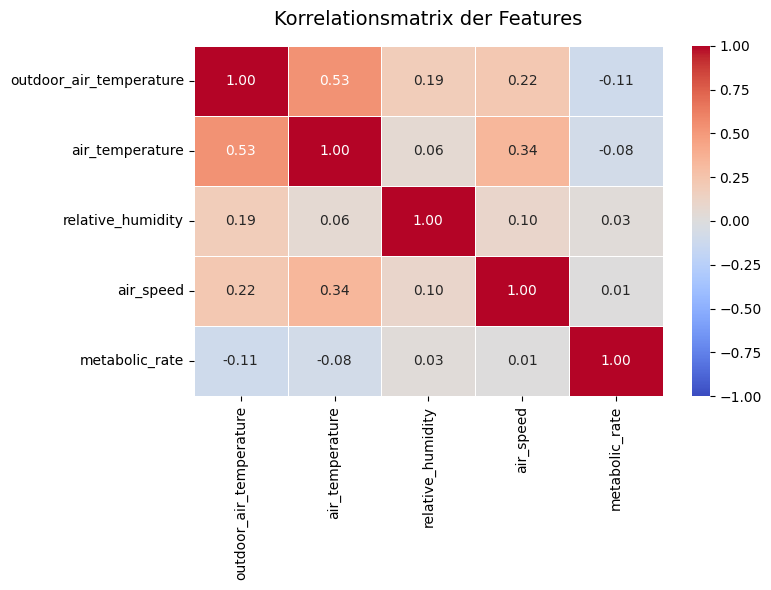

In [13]:
# Korrelationsmatrix

#corr_matrix = df_ml_clo_clean.drop(columns=['cooling_type', 'climate_zone', 'building_type', 'country', 'season', 'clothing_ensemble_insulation']).corr()
corr_matrix = df_ml_clo_clean.drop(columns=['cooling_type', 'climate_zone', 'building_type', 'season', 'clothing_ensemble_insulation']).corr()

# 2. Grafik (Heatmap) erstellen
plt.figure(figsize=(8, 6))

# annot=True schreibt die exakten Zahlenwerte in die Kästchen
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm',  # Blau = negative Korrelation, Rot = positive Korrelation
    fmt=".2f",        # Auf 2 Nachkommastellen runden
    linewidths=0.5,   # Dünne Trennlinien zwischen den Kästchen
    vmin=-1, vmax=1   # Die Farbskala exakt von -1 bis +1 begrenzen
)

plt.title('Korrelationsmatrix der Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [14]:
#sns.pairplot(data=df_ml_clean, hue='clothing_ensemble_insulation', palette="Set2")

## Regression

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import OneHotEncoder, TargetEncoder

X = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation'])
y = df_ml_clo_clean['clothing_ensemble_insulation']

categorial_features = [
    "season",
#    "country",
    "building_type",
    "cooling_type",
    "climate_zone"
]

#climate_features = ["climate"]    # temporär verwendet, aber sehr viele Einträge
#climate_features = ["climate_zone"]    # abgewandelte Spalte mit reduzierter Anzahl an Klimazonen

feature_names = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation']).columns.tolist()

#columns_to_scale = ['air_speed']
columns_to_scale = ['air_speed', 'metabolic_rate']
standard_columns = ['outdoor_air_temperature', 'air_temperature', 'relative_humidity']
other_columns = [col for col in feature_names if col not in columns_to_scale]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ColumnTransformer für gezielte Skalierung
preprocessor = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        ('standard_scale', StandardScaler(), standard_columns),
        ('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features)#,   # sparse_output für GradientBoostingRegrressor
#        ('climate_encoder', TargetEncoder(smooth="auto", cv=5, random_state=42), climate_features)
    ],
    remainder='passthrough' # Verbleibende Spalten bleiben unverändert
)

# manuelles Logarithmieren des targets - als Test (jedoch ohne nennenswerten Einfluss)
#y_train_log = np.log1p(y_train)
#y_test_log = np.log1p(y_test)

In [16]:
# Wurde verwendet, um Werte an die Anomaliebetrachtungen zu übertragen

# Rausschreiben für Isolation Forest zur Anomalieerkennung
#X_train.to_csv('X_train.csv', index=False, sep=';')
#y_train.to_csv('y_train.csv', index=False, sep=';')

#X_test.to_csv('X_test.csv', index=False, sep=';')
#y_test.to_csv('y_test.csv', index=False, sep=';')

In [17]:
# Wurde verwendet, um die Ausgabewerte der Anomaliebetrachtung einzulesen

# Einlesen der Train und Testsets aus der Anomalieerkennung
# R^2 Werte geringfügig schlechter, aber keien anormalen Werte mehr im Trainset
#X_train = pd.read_csv('X_train_cleaned.csv', sep=';')
#y_train = pd.read_csv('y_train_cleaned.csv', sep=';')

# Trainset sollte nur nzgl. Punkten angefasst werden die physikalisch unlogisch sind!!!
# Somit sollte jeder Punkt der als anormal deklariert wurde kontrolliert werden!!!

In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor  
from sklearn.svm import SVR

# Definition der Algorithmen
models = {
    "Linear Regression": LinearRegression(),    #   quasi keine Hyperparameter nur über Regularisierungen oder durch Feature Engineering zu verbessern
    "Linear Regression (mit Polynomen - 2ten Grades)": Pipeline([('poly', PolynomialFeatures(degree=2, interaction_only=True)), ('lr', LinearRegression())]),

# Betrachtete Parameter für Lasso
##    "Lasso Regression": Lasso(alpha=0.1, max_iter=10000, random_state=42),
##    "Lasso Regression (mit Polynomen)": Pipeline([
##        ('poly', PolynomialFeatures(degree=2, interaction_only=True)), 
##        ('lr', Lasso(alpha=0.1, max_iter=10000, random_state=42))
##    ]),

    "Ridge Regression": Ridge(alpha=0.001),
    
##        "Ridge Regression (mit Polynomen, alpha=10.0)": Pipeline([
##        ('poly', PolynomialFeatures(degree=2, interaction_only=True)), 
##        ('lr', Ridge(alpha=0.01))
##    ]),

    "Support Vector Regression": SVR(kernel='rbf'), # nicht effektiv bei vielen Datensätzen!!!

    # SVR mit höherer Toleranz für komplexe Muster (höheres C)
#    "SVR (C=10, epsilon=0.1)": SVR(kernel='rbf', C=10.0, epsilon=0.1), # keine Verbesserung
    
    # SVR mit sehr feiner, lokaler Anpassung (höheres Gamma)
##    "SVR (C=100, gamma=0.1)": SVR(kernel='rbf', C=100.0, gamma=0.1),  # extrem lange Simulationszeit!!! abgebrochen
    
    # Alternativer Kernel für rein lineare/polynomiale Trends (falls RBF nicht performt)
##    "SVR (Linear-Kernel)": SVR(kernel='linear', C=1.0),  # extrem lange Simulationszeit!!! abgebrochen

    #"Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3, min_samples_leaf=5),

#    "Random Forest (Flach)": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3, min_samples_leaf=5),
    
    # Variante 1: Tieferer Wald für komplexere Muster
#    "Random Forest (Medium)": RandomForestRegressor(n_estimators=150, random_state=42, max_depth=8, min_samples_leaf=4),
    
    # Variante 2: Sehr flexibler Wald, bei dem max_features die Overfitting-Bremse zieht
    "Random Forest (Deep & Random)": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15, min_samples_leaf=2, max_features='sqrt'),
#    "Random Forest (Deeper & Random)": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=20, min_samples_leaf=2, max_features='sqrt'),
#    "Random Forest (Deeper & Random)": RandomForestRegressor(n_estimators=1000, random_state=42, max_depth=15, min_samples_leaf=2, max_features='sqrt'),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,          # Entspricht n_estimators bei XGBoost (Anzahl Bäume) 150, 200
        max_depth=10,           # Maximale Tiefe der Bäume   5, 10
        learning_rate=0.15,    # Lernrate / Schrittweite (Overfitting-Bremse)   0.05, 0.15
        random_state=42
    )
}

# Liste, um die Ergebnisse für das Plotten zu speichern
plot_data = []

# Schleife über alle Modelle
for name, model in models.items():
    # Pipeline aus Vorverarbeitung und aktuellem Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Modell trainieren
 #   pipeline.fit(X_train, y_train_log)
    pipeline.fit(X_train, y_train)
    
    # Vorhersagen für Training und Test generieren
#    y_train_pred_log = pipeline.predict(X_train)
#    y_test_pred_log = pipeline.predict(X_test)
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
#    y_train_pred = np.expm1(y_train_pred_log)
#    y_test_pred = np.expm1(y_test_pred_log)

    # Metriken berechnen
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Overfitting-Check: Differenz der R²-Werte
    r2_diff = r2_train - r2_test
    
    print(f"=== {name} ===")
    #print(f"  Train: R² = {r2_train:.4f} | RMSE = {rmse_train:.2f}")
    #print(f"  Test:  R² = {r2_test:.4f}  | RMSE = {rmse_test:.2f}")
    print(f"  Train: R² = {r2_train:.4f} | RMSE = {rmse_train:.2f} | MAE = {mae_train:.2f}")
    print(f"  Test:  R² = {r2_test:.4f} | RMSE = {rmse_test:.2f} | MAE = {mae_test:.2f}")

    print(f"Delta R1: {r2_diff}")

    plot_data.append({"Modell": name, "Datensatz": "Training", "R²-Wert": r2_train})
    plot_data.append({"Modell": name, "Datensatz": "Test", "R²-Wert": r2_test})

    # Warnung ausgeben, wenn das Modell auf den Trainingsdaten deutlich besser ist
    if r2_diff > 0.10:
        print(f"  ⚠️ Warnung: Mögliches Overfitting erkannt! (R²-Differenz: {r2_diff:.4f})")
    elif r2_diff < -0.05:
        print(f"  ℹ️ Modell generalisiert ungewöhnlich gut oder Testset ist zu klein.")
    else:
        print(f"  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).")
    print("-" * 40)


# Es konnte kein Unterschid zwischen logartimierten und nicht logarithmierten Targetwerten festgestellt

=== Linear Regression ===
  Train: R² = 0.3258 | RMSE = 0.23 | MAE = 0.17
  Test:  R² = 0.3045 | RMSE = 0.23 | MAE = 0.17
Delta R1: 0.021237396073958803
  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).
----------------------------------------
=== Linear Regression (mit Polynomen - 2ten Grades) ===
  Train: R² = 0.4978 | RMSE = 0.20 | MAE = 0.14
  Test:  R² = 0.4710 | RMSE = 0.20 | MAE = 0.14
Delta R1: 0.026767447121460286
  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).
----------------------------------------
=== Ridge Regression ===
  Train: R² = 0.3258 | RMSE = 0.23 | MAE = 0.17
  Test:  R² = 0.3045 | RMSE = 0.23 | MAE = 0.17
Delta R1: 0.02123735732234444
  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).
----------------------------------------
=== Support Vector Regression ===
  Train: R² = 0.6140 | RMSE = 0.17 | MAE = 0.12
  Test:  R² = 0.5775 | RMSE = 0.18 | MAE = 0.13
Delta R1: 0.03640052928987969
  ✅ Modell ist stabil (Gute Balance zwischen

Grobe Einschätzung für Ergebnisse:

\(R^{2}\) < 0,30 (Schwach): Das Modell hat kaum Vorhersagekraft. Es übersieht wichtige Muster oder die Daten sind zu verrauscht.<br>
\(R^{2}\) von 0,30 bis 0,50 (Moderat/Akzeptabel): Typisch für komplexe, menschliche oder biologische Systeme. Das Modell hat reale Muster erkannt, liegt aber noch oft daneben.<br>
\(R^{2}\) von 0,50 bis 0,70 (Gut): Ein starkes Ergebnis in der Praxis mit realen Felddaten.<br>
\(R^{2}\) > 0,70 (Sehr gut / Exakt): Wird meist nur in der Physik, bei technischen Anlagen oder im Labor erreicht, wo Prozesse exakt berechenbaren Regeln folgen.<br>

0.52 heißt, dass das Modell zu 52% aus den Features zu erklären ist und zu 48% durch nicht beobachtete Features oder dem Zufdall!

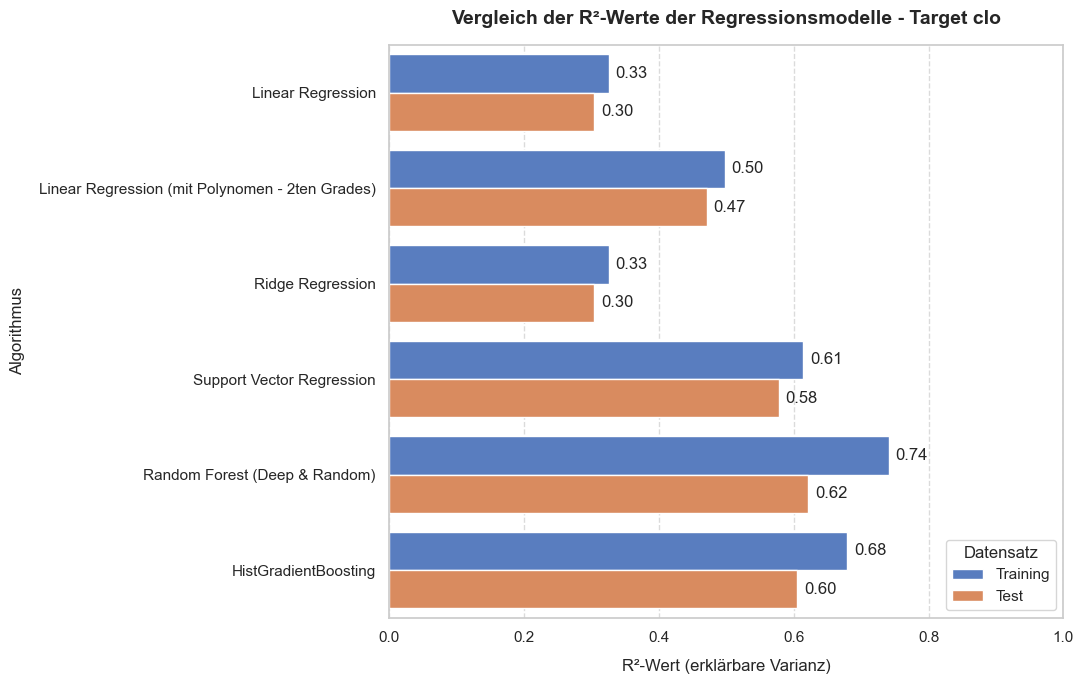

In [19]:
# Vergleich der Ergebnisse der Algorithmen

# Ergebnisse in einen DataFrame umwandeln
df_results = pd.DataFrame(plot_data)

# Grafik-Größe festlegen
#plt.figure(figsize=(10, 6))

plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid") # Sorgt für ein sauberes, modernes Design

# Balkendiagramm erstellen
sns.barplot(
    data=df_results, 
    y="Modell", 
    x="R²-Wert", 
    hue="Datensatz", 
    palette="muted"
)

# Optische Verschönerungen
plt.title("Vergleich der R²-Werte der Regressionsmodelle - Target clo", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("R²-Wert (erklärbare Varianz)", fontsize=12, labelpad=10)
plt.ylabel("Algorithmus", fontsize=12, labelpad=10)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Hintergrundraster

# Werte direkt an den Balken anzeigen
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=5)

plt.legend(title="Datensatz", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


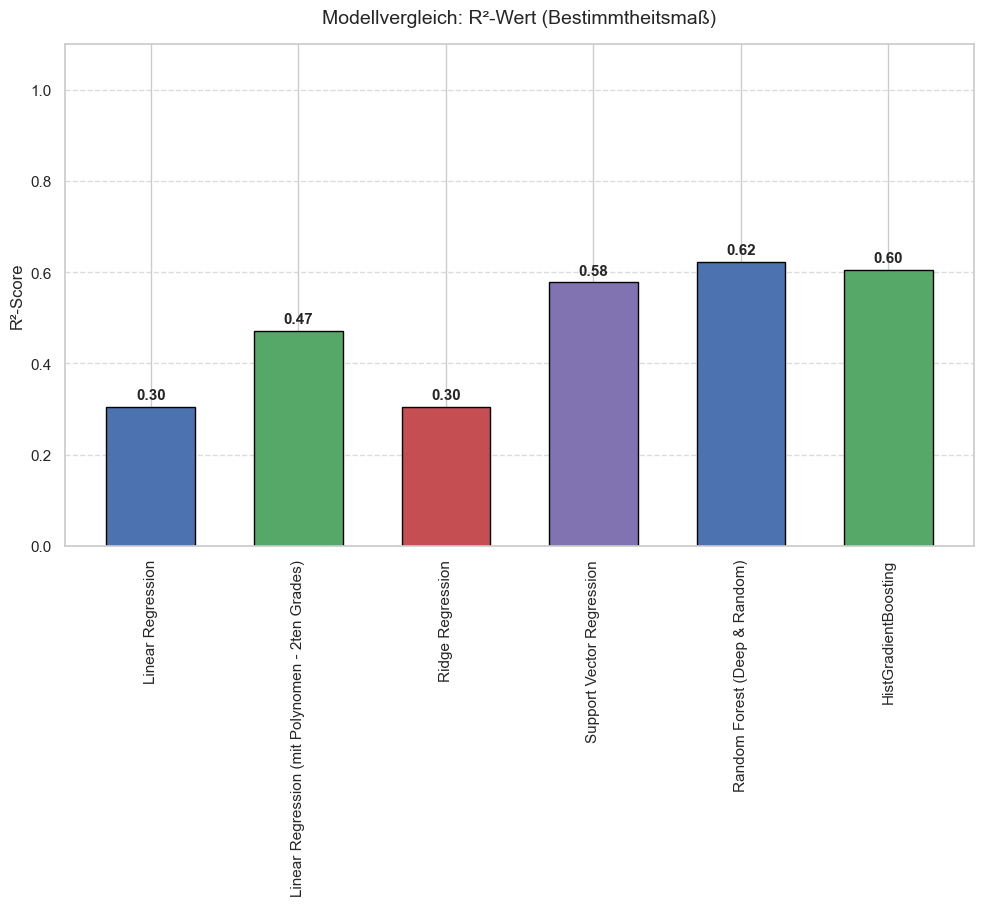

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

# Dictionary, um die Ergebnisse für die Grafik zu speichern
r2_results = {}

# Die Schleife trainiert die Modelle und speichert den R2-Wert
for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", model)
        ]
    )

    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # R2-Score berechnen und speichern
    score = r2_score(y_test, y_pred)
    r2_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Balkendiagramm zeichnen
bars = plt.bar(
    r2_results.keys(),
    r2_results.values(),
    color=farben,
    edgecolor="black",
    width=0.6,
)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    va_dir = "bottom" if height >= 0 else "top"
    offset = 0.01 if height >= 0 else -0.01

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + offset,
        f"{height:.2f}",
        ha="center",
        va=va_dir,
        fontsize=11,
        fontweight="bold",
    )

# Diagramm-Details anpassen
plt.title("Modellvergleich: R²-Wert (Bestimmtheitsmaß)", fontsize=14, pad=15)
plt.ylabel("R²-Score", fontsize=12)

min_y = min(0.0, min(r2_results.values()) - 0.1)
plt.ylim(min_y, 1.1)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


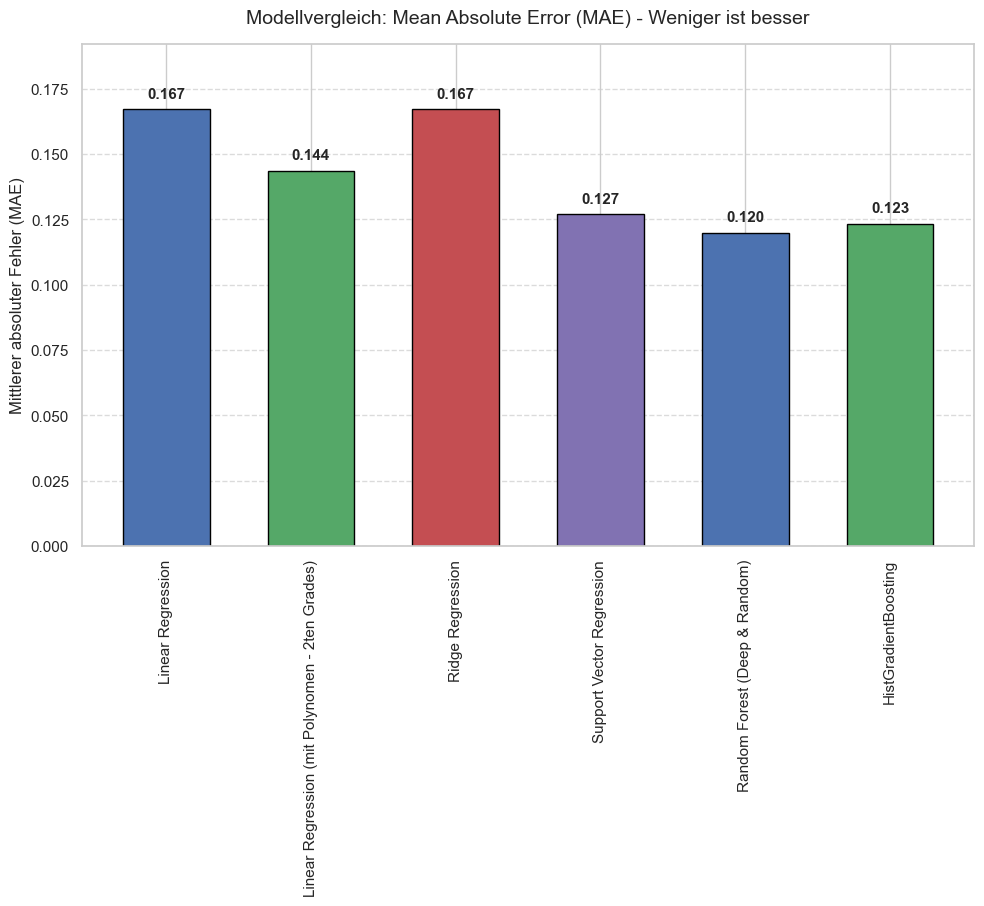

In [21]:
# Vergleich der Algorithmen

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline

# Dictionary für Ergebnisse
mae_results = {}

# Die Schleife trainiert die Modelle und speichert den MAE-Wert
for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", model),
        ]
    )

    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # MAE berechnen und speichern
    score = mean_absolute_error(y_test, y_pred)
    mae_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Balkendiagramm zeichnen
bars = plt.bar(
    mae_results.keys(),
    mae_results.values(),
    color=farben,
    edgecolor="black",
    width=0.6,
)

# Höchsten MAE-Wert ermitteln, um dynamisch Platz für die Labels zu schaffen
max_mae = max(mae_results.values())
text_offset = max_mae * 0.02  # 2% der Höhe als Abstand über dem Balken

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + text_offset,
        f"{height:.3f}",  # <--- .3f für präzisere Fehlerwerte (3 Nachkommastellen)
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Diagramm-Details anpassen
plt.title(
    "Modellvergleich: Mean Absolute Error (MAE) - Weniger ist besser",
    fontsize=14,
    pad=15,
)
plt.ylabel("Mittlerer absoluter Fehler (MAE)", fontsize=12)

# Y-Achse startet starr bei 0 und lässt oben 15% Puffer für die Text-Beschriftungen
plt.ylim(0, max_mae * 1.15)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


### Gridsearch - Anomaliefilter - log. Skalierung clo

Logarithmieren des Targets oben ausprobiert => keine Änderung der Genauigkeit!

In [22]:
'''
from sklearn.model_selection import GridSearchCV

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Nutzt deinen bestehenden preprocessor
    ('regressor', HistGradientBoostingRegressor(loss='absolute_error', random_state=42))
])

# Hyperparameter-Gitter (Param_Grid) definieren

param_grid = {
    'regressor__learning_rate': [0.01, 0.05, 0.1],     # Lernrate des Modells
    'regressor__max_iter': [50, 100, 150, 250],              # Anzahl der Boosting-Schritte (Bäume)
    'regressor__max_leaf_nodes': [15, 31, 63],          # Maximale Anzahl an Blättern pro Baum
    'regressor__min_samples_leaf': [10, 20, 30],        # Mindestanzahl an Datenpunkten pro Blatt
    'regressor__l2_regularization': [0.0, 0.1, 1.0],     # L2-Regularisierung zur Vermeidung von Overfitting
    'regressor__max_depth': [5, 12 ,20 ,50],
    'regressor__early_stopping': [True, None]
}

# 4. GridSearchCV konfigurieren
# cv=5 bedeutet 5-fache Kreuzvalidierung
# n_jobs=-1 nutzt alle verfügbaren CPU-Kerne für maximale Geschwindigkeit
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)   # kein log verwendet

print("\n--- Grid Search abgeschlossen ---")
print(f"Beste Hyperparameter: {grid_search.best_params_}")
print(f"Bester CV-Score (MAE auf Log-Ebene): {-grid_search.best_score_:.4f}\n")


# --- 3. DIE BESTE PIPELINE IN DEINER EVALUATIONS-SCHLEIFE NUTZEN ---

# Wir packen das beste gefundene Modell in dein models-Dictionary
models = {
    "HistGradientBoosting (Optimized via GridSearch)": grid_search.best_estimator_
}

# Liste, um die Ergebnisse für das Plotten zu speichern
plot_data = []

# Schleife über alle Modelle (jetzt nur noch das optimierte HistGradientBoosting)
for name, pipeline in models.items():
    
    # Hinweis: .fit() wurde bereits oben in der Grid Search ausgeführt!
    # Die pipeline enthält bereits das fertig trainierte, beste Modell.
    
    # Vorhersagen für Training und Test generieren
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Logarithmierung rückgängig machen (wie in deiner Vorlage)
#    y_train_pred = np.expm1(y_train_pred_log)
#    y_test_pred = np.expm1(y_test_pred_log)

    # Metriken berechnen (auf den Original-Werten)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Overfitting-Check: Differenz der R²-Werte
    r2_diff = r2_train - r2_test
    
    print(f"=== {name} ===")
    print(f"  Train: R² = {r2_train:.4f} | RMSE = {rmse_train:.2f} | MAE = {mae_train:.2f}")
    print(f"  Test:  R² = {r2_test:.4f}  | RMSE = {rmse_test:.2f}  | MAE = {mae_test:.2f}")

    print(f"Delta R²: {r2_diff:.4f}")

    plot_data.append({"Modell": name, "Datensatz": "Training", "R²-Wert": r2_train})
    plot_data.append({"Modell": name, "Datensatz": "Test", "R²-Wert": r2_test})

    # Warnung ausgeben, wenn das Modell auf den Trainingsdaten deutlich besser ist
    if r2_diff > 0.10:
        print(f"  ⚠️ Warnung: Mögliches Overfitting erkannt! (R²-Differenz: {r2_diff:.4f})")
    elif r2_diff < -0.05:
        print(f"  ℹ️ Modell generalisiert ungewöhnlich gut oder Testset ist zu klein.")
    else:
        print(f"  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).")
    print("-" * 40)
    '''

'\nfrom sklearn.model_selection import GridSearchCV\n\nbase_pipeline = Pipeline(steps=[\n    (\'preprocessor\', preprocessor), # Nutzt deinen bestehenden preprocessor\n    (\'regressor\', HistGradientBoostingRegressor(loss=\'absolute_error\', random_state=42))\n])\n\n# Hyperparameter-Gitter (Param_Grid) definieren\n\nparam_grid = {\n    \'regressor__learning_rate\': [0.01, 0.05, 0.1],     # Lernrate des Modells\n    \'regressor__max_iter\': [50, 100, 150, 250],              # Anzahl der Boosting-Schritte (Bäume)\n    \'regressor__max_leaf_nodes\': [15, 31, 63],          # Maximale Anzahl an Blättern pro Baum\n    \'regressor__min_samples_leaf\': [10, 20, 30],        # Mindestanzahl an Datenpunkten pro Blatt\n    \'regressor__l2_regularization\': [0.0, 0.1, 1.0],     # L2-Regularisierung zur Vermeidung von Overfitting\n    \'regressor__max_depth\': [5, 12 ,20 ,50],\n    \'regressor__early_stopping\': [True, None]\n}\n\n# 4. GridSearchCV konfigurieren\n# cv=5 bedeutet 5-fache Kreuzvalidi

In [23]:
'''
nach 35 min, kein besseres Ergebnis als in ursprünglicher Untersuchung!!!
--- Grid Search abgeschlossen ---
Beste Hyperparameter: {'regressor__early_stopping': True, 'regressor__l2_regularization': 0.1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 12, 'regressor__max_iter': 250, 'regressor__max_leaf_nodes': 63, 'regressor__min_samples_leaf': 30}
Bester CV-Score (MAE auf Log-Ebene): 0.1198

=== HistGradientBoosting (Optimized via GridSearch) ===
  Train: R² = 0.6526 | RMSE = 0.17 | MAE = 0.11
  Test:  R² = 0.5948  | RMSE = 0.18  | MAE = 0.12
Delta R²: 0.0578
  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).
----------------------------------------
'''

"\nnach 35 min, kein besseres Ergebnis als in ursprünglicher Untersuchung!!!\n--- Grid Search abgeschlossen ---\nBeste Hyperparameter: {'regressor__early_stopping': True, 'regressor__l2_regularization': 0.1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 12, 'regressor__max_iter': 250, 'regressor__max_leaf_nodes': 63, 'regressor__min_samples_leaf': 30}\nBester CV-Score (MAE auf Log-Ebene): 0.1198\n\n=== HistGradientBoosting (Optimized via GridSearch) ===\n  Train: R² = 0.6526 | RMSE = 0.17 | MAE = 0.11\n  Test:  R² = 0.5948  | RMSE = 0.18  | MAE = 0.12\nDelta R²: 0.0578\n  ✅ Modell ist stabil (Gute Balance zwischen Train und Test).\n----------------------------------------\n"

### SHAP-Analyse

In [24]:
import shap
import matplotlib.pyplot as plt

# Nachbau des vermeindlich besten Systems für die SHAP-Analyse
best_model_name = "HistGradientBoosting"
#best_model_name = "Random Forest (Deep & Random)"

pipeline_to_explain = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', models[best_model_name])
])
# Erneuter Fit zur Sicherheit, falls die Schleife oben nicht die trainierte Pipeline speichert
pipeline_to_explain.fit(X_train, y_train)

# Featurenamen nach der Transformation extrahieren
# get_feature_names_out() liefert die Namen für One-Hot, TargetEncoder etc.
transformed_feature_names = pipeline_to_explain.named_steps['preprocessor'].get_feature_names_out()

# Testdaten transformieren, um sie dem Explainer zu übergeben
X_test_transformed = pipeline_to_explain.named_steps['preprocessor'].transform(X_test)

# speichern in einen dataframe zum evtl. späteren Zugriff
X_test_df = pd.DataFrame(X_test_transformed, columns=transformed_feature_names)

# SHAP Explainer initialisieren und Werte berechnen
# TreeExplainer ist optimiert für HistGradientBoosting und RandomForest
explainer = shap.TreeExplainer(pipeline_to_explain.named_steps['regressor'])
#shap_values = explainer(X_test_df)

In [25]:
shap_values_raw = explainer(X_test_df)

# Zusammenfassen der One-Hot-Spalten auf die ursprünglichen 10 Features
# Gruppieren der Spalten anhand ihres Präfixes (z.B. 'cat__season_winter' -> 'season')
original_features = ['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 
#                     'season', 'country', 'building_type', 'air_speed', 
                     'season', 'building_type', 'air_speed', 
                     'metabolic_rate', 'climate_zone', 'cooling_type']

# Neue leere Arrays für die zusammengefassten Daten erstellen
collapsed_values = np.zeros((X_test_df.shape[0], len(original_features)))
collapsed_data = np.zeros((X_test_df.shape[0], len(original_features)))

for i, orig_feat in enumerate(original_features):
    # Finde alle transformierten Spaltennamen, die den Namen des Original-Features enthalten
    matching_cols = [col for col in X_test_df.columns if orig_feat in col]
    matching_indices = [X_test_df.columns.get_loc(col) for col in matching_cols]
    
    # SHAP-Werte für alle zusammengehörigen Kategorien aufaddieren
    collapsed_values[:, i] = shap_values_raw.values[:, matching_indices].sum(axis=1)
    
    # Den tatsächlichen Wert abbilden
    # Bei numerischen Werten den Wert direkt verwenden.
    # Bei One-Hot-Kategorien einen Platzhalter (oder den Max-Wert).
    if len(matching_indices) == 1:
        collapsed_data[:, i] = X_test_df.iloc[:, matching_indices[0]]
    else:
        # Repräsentiert die aktivierte Kategorie (wo die 1 im One-Hot-Encoding steht)
        collapsed_data[:, i] = X_test_df.iloc[:, matching_indices].max(axis=1)

# Ein neues SHAP-Explanationobjekt definieren
from shap import Explanation
shap_values_collapsed = Explanation(
    values=collapsed_values,
    base_values=shap_values_raw.base_values,
    data=collapsed_data,
    feature_names=original_features
)


=== Globales SHAP-Balkendiagramm für HistGradientBoosting ===


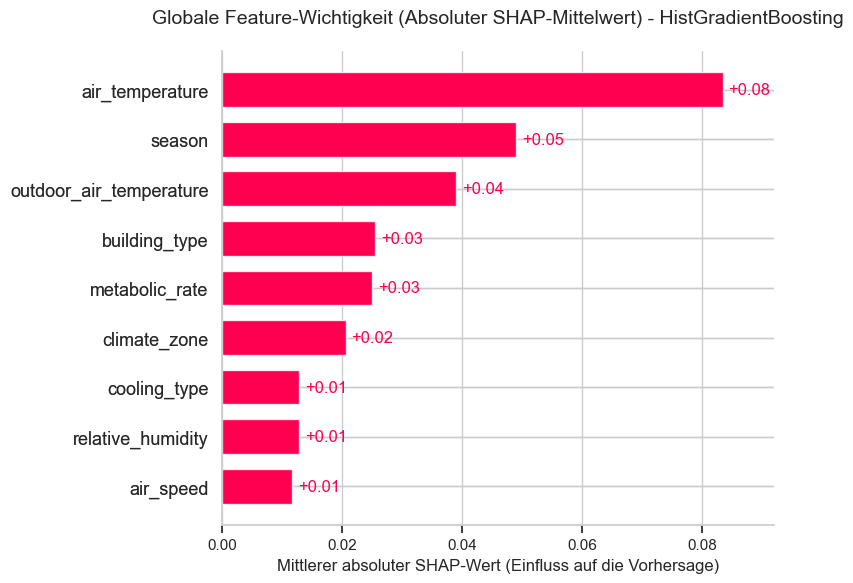

In [26]:
print(f"\n=== Globales SHAP-Balkendiagramm für {best_model_name} ===")
plt.figure(figsize=(10, 6))

# Generiert ein sauberes, sortiertes Balkendiagramm der globalen Wichtigkeit
shap.plots.bar(shap_values_collapsed, max_display=15, show=False)

plt.title(f"Globale Feature-Wichtigkeit (Absoluter SHAP-Mittelwert) - {best_model_name}", fontsize=14, pad=20)
plt.xlabel("Mittlerer absoluter SHAP-Wert (Einfluss auf die Vorhersage)", fontsize=12)
plt.tight_layout()
plt.show()


=== Globale SHAP-Analyse für HistGradientBoosting ===


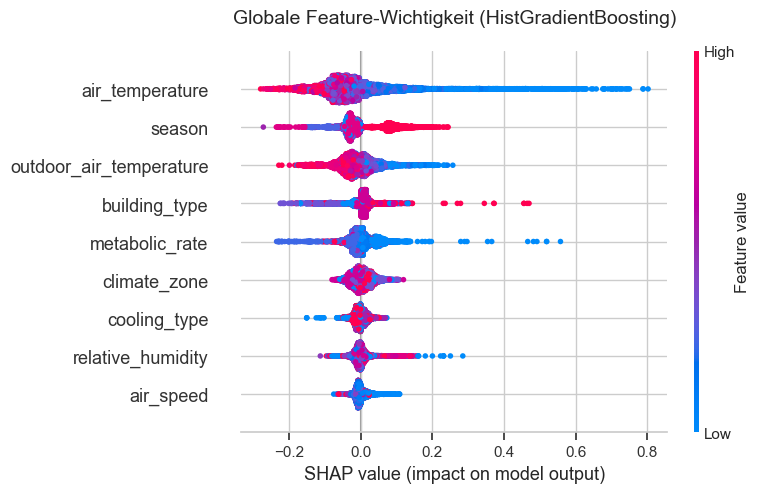

In [27]:
# --- GLOBALE ANALYSE (Summary Plot mit 10 komprimierten Features) ---
print(f"\n=== Globale SHAP-Analyse für {best_model_name} ===")

# saubere 10-Spaltenkopie des originalen, untransformierten X_test
X_test_summary = X_test.copy()

# Textspalten in numerische Codes umwandeln, damit SHAP sie plotten kann
for col in X_test_summary.select_dtypes(include=['object', 'category']).columns:
    X_test_summary[col] = X_test_summary[col].astype('category').cat.codes

# Grafik mit perfekt übereinstimmenden 10 Spalten
plt.figure(figsize=(10, 6))

# WICHTIG: angepasste 10-Spalten-DataFrame X_test_summary übergeben
shap.summary_plot(shap_values_collapsed, X_test_summary, show=False)

plt.title(f"Globale Feature-Wichtigkeit ({best_model_name})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()



=== Wasserfalldiagramm für die erste Test-Instanz ===


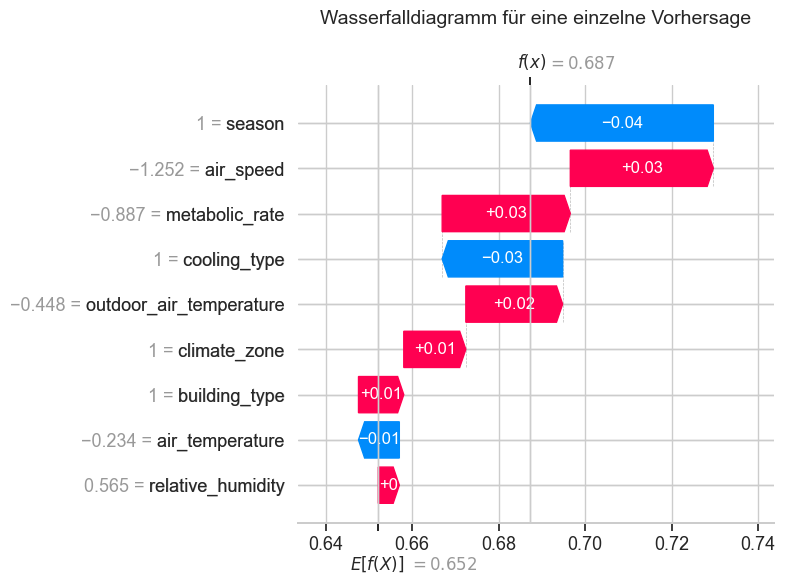

In [28]:
# --- LOKALE ANALYSE (Wasserfalldiagramm für die erste Testinstanz) ---
print(f"\n=== Wasserfalldiagramm für die erste Test-Instanz ===")
plt.figure(figsize=(10, 6))
# shap_values[0] nimmt die allererste Zeile aus deinem Testset
# max_display=10 begrenzt die Anzeige auf die 10 wichtigsten Einflussfaktoren dieser Instanz
shap.plots.waterfall(shap_values_collapsed[0], max_display=10, show=False)
plt.title(f"Wasserfalldiagramm für eine einzelne Vorhersage", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Vorhersagen und Speicherung

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

'''
# Die beste Konfiguration definieren
best_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True)),
    ('lr', LinearRegression())
])
'''


best_model = Pipeline([
    #("Random Forest (Deep & Random)", RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15, min_samples_leaf=2, max_features='sqrt'))
    ('hgb', HistGradientBoostingRegressor(
        max_iter=200,          # Entspricht n_estimators bei XGBoost (Anzahl Bäume) 150
        max_depth=10,           # Maximale Tiefe der Bäume   5
        learning_rate=0.15,    # Lernrate / Schrittweite (Overfitting-Bremse)   0.05
        random_state=42
    ))
])


'''
best_model = Pipeline([
    ("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15, min_samples_leaf=2, max_features='sqrt'))
])
'''

# Die finale Pipeline inklusive Vorverarbeitung erstellen
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Ihr bestehender ColumnTransformer
    ('regressor', best_model)       # Das polynomiale Modell
])

# Ein letztes Mal mit den Trainingsdaten füttern
final_pipeline.fit(X_train, y_train)

y_train_pred = final_pipeline.predict(X_train)
y_test_pred = final_pipeline.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

In [30]:
# Beispielvorhersage
neue_daten = pd.DataFrame({
    'outdoor_air_temperature': [10.7, 24.40],   # die ersten beiden Punkte aus X_test
    'air_temperature': [19.2, 26.7],
    'relative_humidity': [54.8, 50.3],
    'season': ['winter', 'summer'],     # Kategorische Spalte 1 (wird automatisch encodiert) - falsche Eingabe führt zum Ignorieren des Wertes!!!
    'country': ['uk', 'pakistan'],      # Kategorische Spalte 2
    'building_type': ['classroom', 'office'], # Kategorische Spalte 3
    'air_speed': [0.09, 0.1444],          # Die numerische Spalte (wird automatisch skaliert)
    'metabolic_rate': [1.2, 1.00683],
    'climate_zone': ['Temperate','Temperate'],
    'cooling_type': ['naturally ventilated', 'naturally ventilated']
})

# Vorhersage berechnen
vorhersagen = final_pipeline.predict(neue_daten)

# Ergebnisse übersichtlich anzeigen
for i, vorhersage in enumerate(vorhersagen):
    print(f"Person {i+1}: Vorhergesagter Kleidungs-Isolationswert = {vorhersage:.2f} Clo")

Person 1: Vorhergesagter Kleidungs-Isolationswert = 0.75 Clo
Person 2: Vorhergesagter Kleidungs-Isolationswert = 0.58 Clo


In [31]:
import joblib

metrics = {
    "y_train_pred" : y_train_pred,
    "y_test_pred" : y_test_pred,
    "r2_train" : r2_train,
    "r2_test" : r2_test,
    "rmse_train" : rmse_train,
    "rmse_test" : rmse_test,
    "mae_train" : mae_train,
    "mae_test" : mae_test
}

regression = {
    "model" : pipeline_to_explain,  # hier steckt alles drinnen, inkl. dem Preprocessing
    "metrics" : metrics,
    "explainer": explainer,
    "shap_values_raw": shap_values_raw,
    "shap_values": shap_values_collapsed,
    "X_test_summary": X_test_summary
}

# Speicherpfad und Dateiname definieren
modell_dateiname = 'finales_regressions_modell_HistGradientBoosting_sk1_9_0.joblib'
#modell_dateiname = 'finales_regressions_modell_RandomForest.joblib'

# Die komplette Pipeline (inklusive Vorverarbeitung und Polynomen) speichern
#joblib.dump(regression, modell_dateiname)

print(f"✅ Das Modell wurde erfolgreich unter '{modell_dateiname}' gespeichert!")


✅ Das Modell wurde erfolgreich unter 'finales_regressions_modell_HistGradientBoosting_sk1_9_0.joblib' gespeichert!


In [32]:
# Laden eines gespeicherten Modells
'''
import pandas as pd
import joblib

# 1. Das gespeicherte Modell aus der Datei laden
geladenes_modell = joblib.load('finales_regressions_modell.joblib')

# 2. Neue Daten bereitstellen (müssen als DataFrame mit den gleichen Spaltennamen vorliegen)
neue_daten = pd.DataFrame({
    'outdoor_air_temperature': [20.1],
    'air_temperature': [18.1],
    'relative_humidity': [60],
    'season': ['winter'],     # Kategorische Spalte 1 (wird automatisch encodiert)
    'country': ['Germany'],      # Kategorische Spalte 2
    'building_type': ['office'], # Kategorische Spalte 3
    'air_speed': [0.15]          # Die numerische Spalte (wird automatisch skaliert)
})

# 3. Direkt die Vorhersage berechnen
vorhersage = geladenes_modell.predict(neue_daten)
print(f"Vorhergesagter Wert: {vorhersage[0]:.2f} Clo")
'''

'\nimport pandas as pd\nimport joblib\n\n# 1. Das gespeicherte Modell aus der Datei laden\ngeladenes_modell = joblib.load(\'finales_regressions_modell.joblib\')\n\n# 2. Neue Daten bereitstellen (müssen als DataFrame mit den gleichen Spaltennamen vorliegen)\nneue_daten = pd.DataFrame({\n    \'outdoor_air_temperature\': [20.1],\n    \'air_temperature\': [18.1],\n    \'relative_humidity\': [60],\n    \'season\': [\'winter\'],     # Kategorische Spalte 1 (wird automatisch encodiert)\n    \'country\': [\'Germany\'],      # Kategorische Spalte 2\n    \'building_type\': [\'office\'], # Kategorische Spalte 3\n    \'air_speed\': [0.15]          # Die numerische Spalte (wird automatisch skaliert)\n})\n\n# 3. Direkt die Vorhersage berechnen\nvorhersage = geladenes_modell.predict(neue_daten)\nprint(f"Vorhergesagter Wert: {vorhersage[0]:.2f} Clo")\n'

### Anomalie Regression über Vorhersage

 Große Differenzen zwichen Vorhersage und Targetwert werden als Anomalie betrachtet

In [33]:
#df_vergleich_reg = pd.DataFrame(y_test.round(decimals=2).copy()).rename(columns={y_test.name: 'Ziel'})

df_vergleich_reg = X_test.copy()

df_vergleich_reg['Ziel'] = pd.DataFrame(y_test.round(decimals=2).copy())

df_vergleich_reg['berechnet'] = final_pipeline.predict(X_test).round(decimals=2)
df_vergleich_reg['delta'] = (df_vergleich_reg['Ziel'] - df_vergleich_reg['berechnet']).round(decimals=2)

print(f"Maximale Abweichung: {df_vergleich_reg['delta'].max()}")
print(f"Minimale Abweichung: {df_vergleich_reg['delta'].min()}")

display(df_vergleich_reg)

Maximale Abweichung: 1.86
Minimale Abweichung: -0.8


,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,climate_zone,cooling_type,Ziel,berechnet,delta
75250,16.150000,24.000000,59.0,cool/dry,office,0.020000,1.0,Dry,air conditioned,0.72,0.66,0.06
66966,18.000000,23.600000,56.7,summer,office,0.200000,1.2,Temperate,naturally ventilated,0.44,0.55,-0.11
11407,26.916667,31.645833,33.8,summer,office,0.310250,1.0,Temperate,naturally ventilated,0.39,0.38,0.01
61806,24.300000,24.700000,58.0,summer,office,0.090000,1.3,Temperate,mixed mode,0.52,0.49,0.03
16162,23.520000,25.200000,58.6,cool/dry,multifamily housing,0.000000,1.2,Tropical,naturally ventilated,0.48,0.57,-0.09
...,...,...,...,...,...,...,...,...,...,...,...,...
9223,29.300000,32.000000,66.4,hot/wet,office,0.120000,1.1,Tropical,naturally ventilated,0.62,0.54,0.08
22887,18.500000,22.000000,55.1,summer,office,0.045796,1.2,Temperate,naturally ventilated,0.87,0.64,0.23
66732,15.290000,24.100000,28.4,winter,office,0.050000,1.2,Temperate,mixed mode,0.60,0.60,0.00
90474,35.250000,25.100000,47.2,summer,office,0.040000,1.3,Temperate,naturally ventilated,0.48,0.63,-0.15


In [34]:
#deltas = np.abs(y_test - y_pred)
deltas = np.abs(df_vergleich_reg['delta'])

# 2. Definiere die Grenze bei den 5% extremsten Abweichungen (95. Perzentil)
anomalie_grenze_95 = np.percentile(deltas, 95)
# Definiere die Grenze für "starke Anomalien" bei den obersten 1%
anomalie_grenze_99 = np.percentile(deltas, 99)

print(f"Ab einem Delta von {anomalie_grenze_95:.2f} clo liegt ein Datensatz in den Top 5% der Fehler.")
print(f"Ab einem Delta von {anomalie_grenze_99:.2f} clo liegt ein Datensatz in den Top 1% (Starke Anomalie).")

Ab einem Delta von 0.34 clo liegt ein Datensatz in den Top 5% der Fehler.
Ab einem Delta von 0.55 clo liegt ein Datensatz in den Top 1% (Starke Anomalie).


In [35]:
# Zusatzinformationen hinzufügen und als df abspeichern für Präsentation

df_regression_anomalie = df_vergleich_reg[np.abs(df_vergleich_reg['delta']) >= anomalie_grenze_99]
df_regression_anomalie['delta_abs'] = np.abs(df_regression_anomalie['delta'])

df_regression_anomalie['country'] = df['country']

display(df_regression_anomalie)

# Abspeichern der Werte die dem 1% obersten Bereich entsprechen in eine Datei für Streamlit
df_regression_anomalie.drop(columns=['delta']).to_csv("df_regression_anomalie.csv", index=False)

C:\Users\User\AppData\Local\Temp\ipykernel_11312\3396650890.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression_anomalie['delta_abs'] = np.abs(df_regression_anomalie['delta'])
C:\Users\User\AppData\Local\Temp\ipykernel_11312\3396650890.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression_anomalie['country'] = df['country']


,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,climate_zone,cooling_type,Ziel,berechnet,delta,delta_abs,country
89730,15.00,23.4,40.9,winter,office,0.010000,1.100000,Temperate,mixed mode,1.48,0.82,0.66,0.66,india
19839,13.50,17.8,67.7,winter,office,0.154000,0.767918,Dry,naturally ventilated,2.29,1.25,1.04,1.04,pakistan
7635,-16.65,23.1,10.7,winter,office,0.090000,1.000000,Continental,air conditioned,1.50,0.68,0.82,0.82,canada
67861,10.20,18.3,47.4,winter,office,0.070000,1.200000,Temperate,naturally ventilated,1.97,1.36,0.61,0.61,iran
7272,18.80,23.1,43.1,summer,office,0.090000,1.300000,Continental,air conditioned,1.60,0.58,1.02,1.02,canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18697,21.30,22.2,17.3,winter,office,0.048563,0.887372,Dry,naturally ventilated,1.63,1.04,0.59,0.59,pakistan
20859,6.80,19.8,44.2,winter,office,0.061231,1.006826,Dry,naturally ventilated,1.76,1.08,0.68,0.68,pakistan
106105,-15.40,17.6,59.8,winter,classroom,0.100000,1.200000,Temperate,mixed mode,1.94,1.11,0.83,0.83,china
91323,13.40,16.7,21.9,winter,office,0.040000,1.100000,Temperate,naturally ventilated,0.90,1.66,-0.76,0.76,india


count    47584.000000
mean         0.650859
std          0.279768
min          0.030000
25%          0.470420
50%          0.620000
75%          0.750000
max          2.870000
Name: clothing_ensemble_insulation, dtype: float64


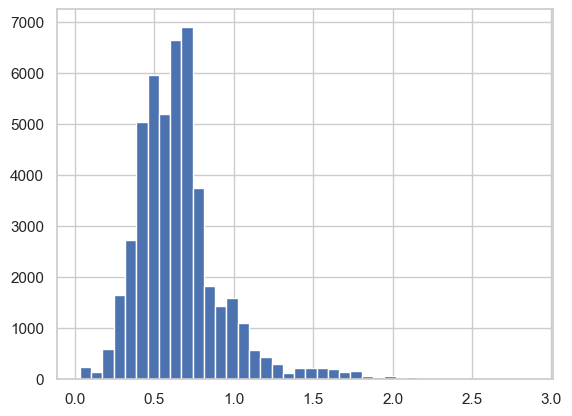

In [36]:
print(y.describe())

y.hist(bins=40)
plt.show()

In [37]:
db_grosse_abw = df_vergleich_reg[df_vergleich_reg['delta']>1]   #   Annahme delta von 1.0 als Grenze für eine Anomalie
db_grosse_abw   #   8 Datensätze mit vermeindlich großer Anomalie gefunden!!!

,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,climate_zone,cooling_type,Ziel,berechnet,delta
19839,13.50,17.8,67.7,winter,office,0.154,0.767918,Dry,naturally ventilated,2.29,1.25,1.04
7272,18.80,23.1,43.1,summer,office,0.090,1.300000,Continental,air conditioned,1.60,0.58,1.02
106181,-0.45,27.0,74.2,winter,classroom,0.100,1.200000,Temperate,mixed mode,1.88,0.71,1.17
106218,7.90,19.5,74.6,winter,classroom,0.000,1.200000,Temperate,mixed mode,1.80,0.75,1.05
16218,29.22,31.7,57.1,hot/wet,multifamily housing,0.130,0.700000,Tropical,naturally ventilated,2.34,0.48,1.86
45493,22.25,26.8,77.7,hot/wet,multifamily housing,0.680,1.600000,Tropical,naturally ventilated,1.49,0.44,1.05
106200,0.15,18.9,59.2,winter,classroom,0.000,1.200000,Temperate,mixed mode,1.90,0.79,1.11
233,12.96,20.9,42.0,winter,office,0.140,0.985495,Temperate,air conditioned,1.78,0.75,1.03
16150,25.70,26.3,51.3,cool/dry,multifamily housing,0.000,1.900000,Tropical,naturally ventilated,2.28,0.63,1.65
106154,0.65,20.7,55.5,winter,classroom,0.130,1.200000,Temperate,mixed mode,2.01,0.92,1.09


Sehr interessant. 8 Werte mit sehr großen Abweichungen in den clo Werten. KONTEXTBEZOGENE ANOMALIEERKENNUNG


SHAP oder Featureimportance könnten weiterführend helfen die Werte einzuordnen.

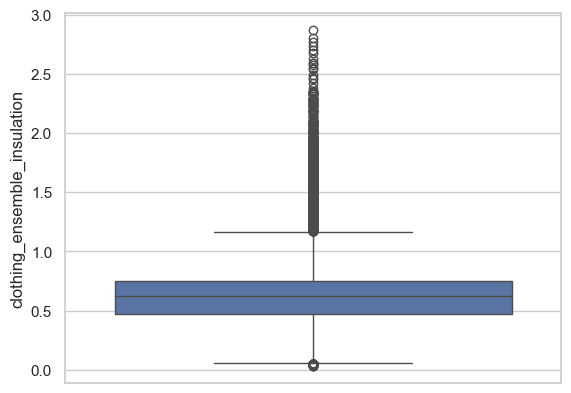

In [38]:
# sns.boxenplot(data=y)
# plt.show()
sns.boxplot(data=y)
plt.show()